# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [2]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


In [3]:
rat_markers = {}
sequence = {}

# INTACT RATS
animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']


m, f = 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in animalList if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in animalList if 'F' in x]), start_intensity=80)

for index, animal in enumerate(animalList):
    print(f'Loading data for {animal}')
    # define marker and color for each rat, used in plots
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', '-']
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', '-']
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")

Loading data for RatF00
Loading data for RatF01
Loading data for RatF02
Loading data for RatM00
Loading data for RatM01
Loading data for RatM02
Loading data for RatF32
Loading data for RatF33
Loading data for RatM31
Loading data for RatM32
Loading data for RatF42
Loading data for RatM40
Loading data for RatM43
Loading data for RatM53
Loading data for RatM54


# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

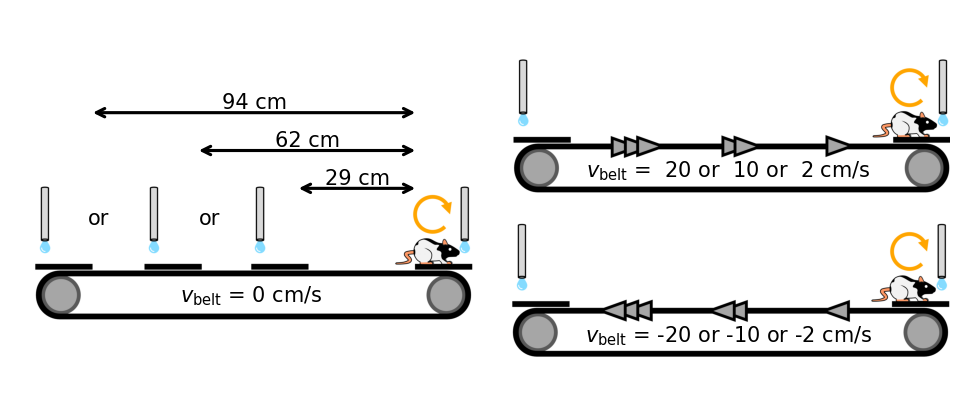

In [4]:
def Figure3A(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Aidle.png"

    img = plt.imread(path)
    img = img[300:2600, 150:3075]
    img = np.concatenate((np.ones((300, img.shape[1], 3), dtype=np.uint8), img), axis=0)
    
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ = 0 cm/s', x=img.shape[1]/2, y=1760, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=450, y=1250, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=1185, y=1250, ha="center", va="center", fontsize=5)

    ax.annotate(text='', xy=(1720, 1050), xytext=(2600, 1050), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(1060, 800), xytext=(2600, 800), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(360, 550), xytext=(2600, 550), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    
    ax.annotate(text='29 cm', xy=(0, 0), xytext=((1720+2600)/2, 1050), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='62 cm', xy=(0, 0), xytext=((1060+2600)/2, 800), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='94 cm', xy=(0, 0), xytext=((360+2600)/2, 550), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)

def Figure3D(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Didle.png"

    img = plt.imread(path)
    img = img[:, 150:3075]
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ =  20 or  10 or  2 cm/s', x=img.shape[1]/2, y=930, ha="center", va="center", fontsize=5)
    ax.text(s=r'$v_{\mathrm{belt}}$ = -20 or -10 or -2 cm/s', x=img.shape[1]/2, y=2020, ha="center", va="center", fontsize=5)

fig, axs = plt.subplots(1, 2, figsize=(cm2inch(8), cm2inch(4)))
Figure3A(ax=axs[0])
Figure3D(ax=axs[1])

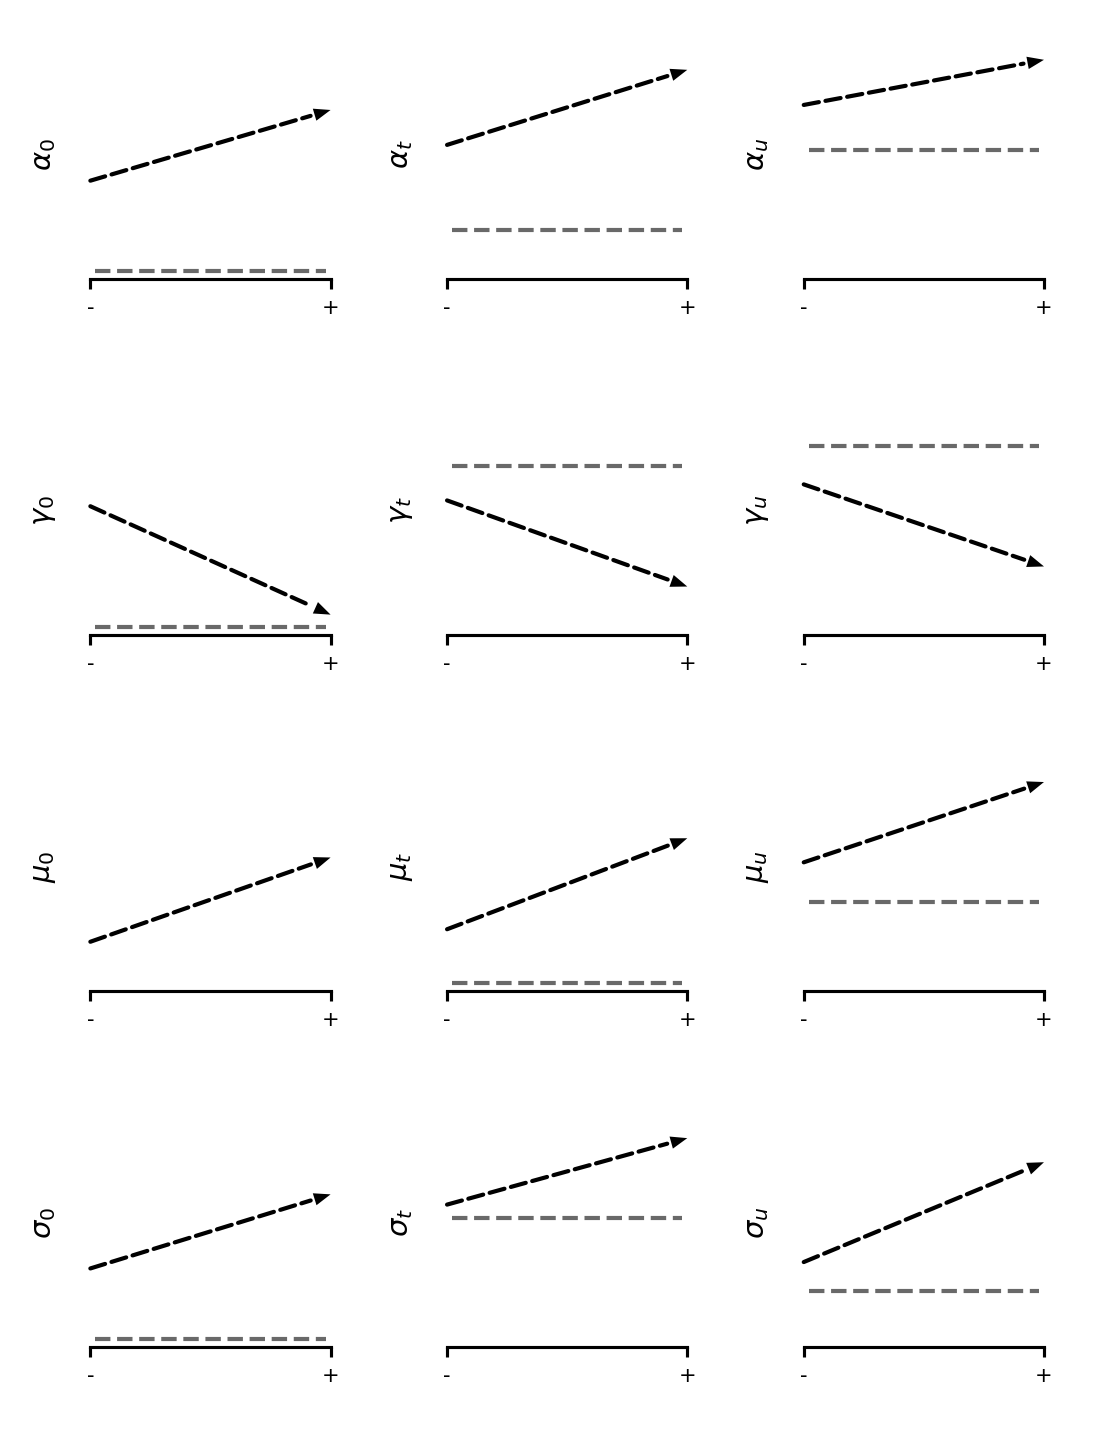

In [5]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, ex_fit= ex_alpha_0, yticks=[0, 1, 2, 3], ylabel=r'$\alpha_0$', start='med', end=2),
    'alpha_t':  dict(fit=alpha_t, ex_fit= ex_alpha_t, yticks=[-.1, 0, .1, .2, .3, .4, .5], ylabel=r'$\alpha_t$', start='med', end=0.4),
    'alpha_u':  dict(fit=alpha_u, ex_fit= ex_alpha_u, yticks=[-.4, -.2, 0, .2, .4], ylabel=r'$\alpha_u$', start=.15, end=.3),
    'gamma_0':  dict(fit=gamma_0, ex_fit= ex_gamma_0, yticks=[0, 0.5, 1, 1.5, 2], ylabel=r'$\gamma_0$', start=1, end=.1),
    'gamma_t':  dict(fit=gamma_t, ex_fit= ex_gamma_t, yticks=[-.2, -.1, 0, .1], ylabel=r'$\gamma_t$', start='med', end=-.15),
    'gamma_u':  dict(fit=gamma_u, ex_fit= ex_gamma_u, yticks=[-.6, -.4, -.2, 0, .2], ylabel=r'$\gamma_u$', start='med', end=-.4),
    'mu_0':     dict(fit=mu_0, ex_fit= ex_mu_0, yticks=[.5, 1, 1.5, 2, 2.5], ylabel=r'$\mu_0$', start='med', end='med'),
    'mu_t':     dict(fit=mu_t, ex_fit= ex_mu_t, yticks=[0, 0.05, .10, .15, .2], ylabel=r'$\mu_t$', start='med', end=.12),
    'mu_u':     dict(fit=mu_u, ex_fit= ex_mu_u, yticks=[-.1, 0, .1, .2], ylabel=r'$\mu_u$', start=0.05, end=.15),
    'sigma_0':  dict(fit=sigma_0, ex_fit= ex_sigma_0, yticks=[0, .05, .1, .15, .2, .25], ylabel=r'$\sigma_0$', start='med', end=.15),
    'sigma_t':  dict(fit=sigma_t, ex_fit= ex_sigma_t, yticks=[-.06, -.03, 0, .03, .06], ylabel=r'$\sigma_t$', start='med', end=0.04),
    'sigma_u':  dict(fit=sigma_u, ex_fit= ex_sigma_u, yticks=[-.03, 0, .03, .06, .09, .12], ylabel=r'$\sigma_u$', start='med', end=0.08),
}

def plot_prediction(param_name, ax=None, show_xlabel=False, show_ylabel=True):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]

    if isinstance(params['start'], str):
        if params['start'] == 'med':
            start = np.median([params['fit'][animal]["60"] for animal in animalList])
    elif isinstance(params['start'], (float, int)):
        start = params['start']
    else:
        raise ValueError("Start value must be a string ('med') or a float/int.")

    if isinstance(params['end'], str):
        if params['end'] == 'med':
            end = np.median([params['fit'][animal]["rev20"] for animal in animalList])
        if params['end'] == 'start':
            end = start
    elif isinstance(params['end'], (float, int)):
        end = params['end']
    else:
        raise ValueError("End value must be a string ('med', 'start') or a float/int.")

    mock_data = [start, start + (end - start) / 2, end]
    # ax.plot([0, 1, 2], mock_data, color='k', lw=.75, markersize=2, linestyle='-')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)


    arrowStart = (0, mock_data[0])
    arrowStop = (2, mock_data[2])
    arrowColor = 'k'
    ax.annotate("", arrowStop, xytext=arrowStart, arrowprops=dict(arrowstyle="-", shrinkA=0, shrinkB=5, edgecolor=arrowColor, facecolor="none", linestyle="dashed"))
    ax.annotate("", arrowStop, xytext=arrowStart, arrowprops=dict(linewidth=0, arrowstyle="-|>,head_width=0.15,head_length=0.4", shrinkA=0, shrinkB=0, edgecolor="none", facecolor=arrowColor, linestyle="solid"))


    ax.set_xlim(0, 2)
    ax.set_xticks([0, 2])
    ax.set_xticklabels(["-", "+"])
    if show_xlabel:
        ax.set_xlabel("Cost")
    else:
        ax.set_xlabel(" ")


    ax.set_ylim(params['yticks'][0], params['yticks'][-1])
    ax.set_yticks(params['yticks'])
    ax.yaxis.set_major_formatter('{x:<5.2f}')
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, labelleft=False)

    if show_ylabel:
        ax.set_ylabel(params['ylabel'])

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)


fig, axs = plt.subplots(4, 3, figsize=(cm2inch(9), cm2inch(12)),
                        gridspec_kw={'width_ratios': [1, 1, 1]})

param_names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u',
               'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']

for ax, param_name in zip(axs.ravel(), param_names):
    plot_prediction(param_name, ax=ax)


# 3B Effect of distance on α0, αt and αu
# 3C Effect of distance on γ0, γt and γu

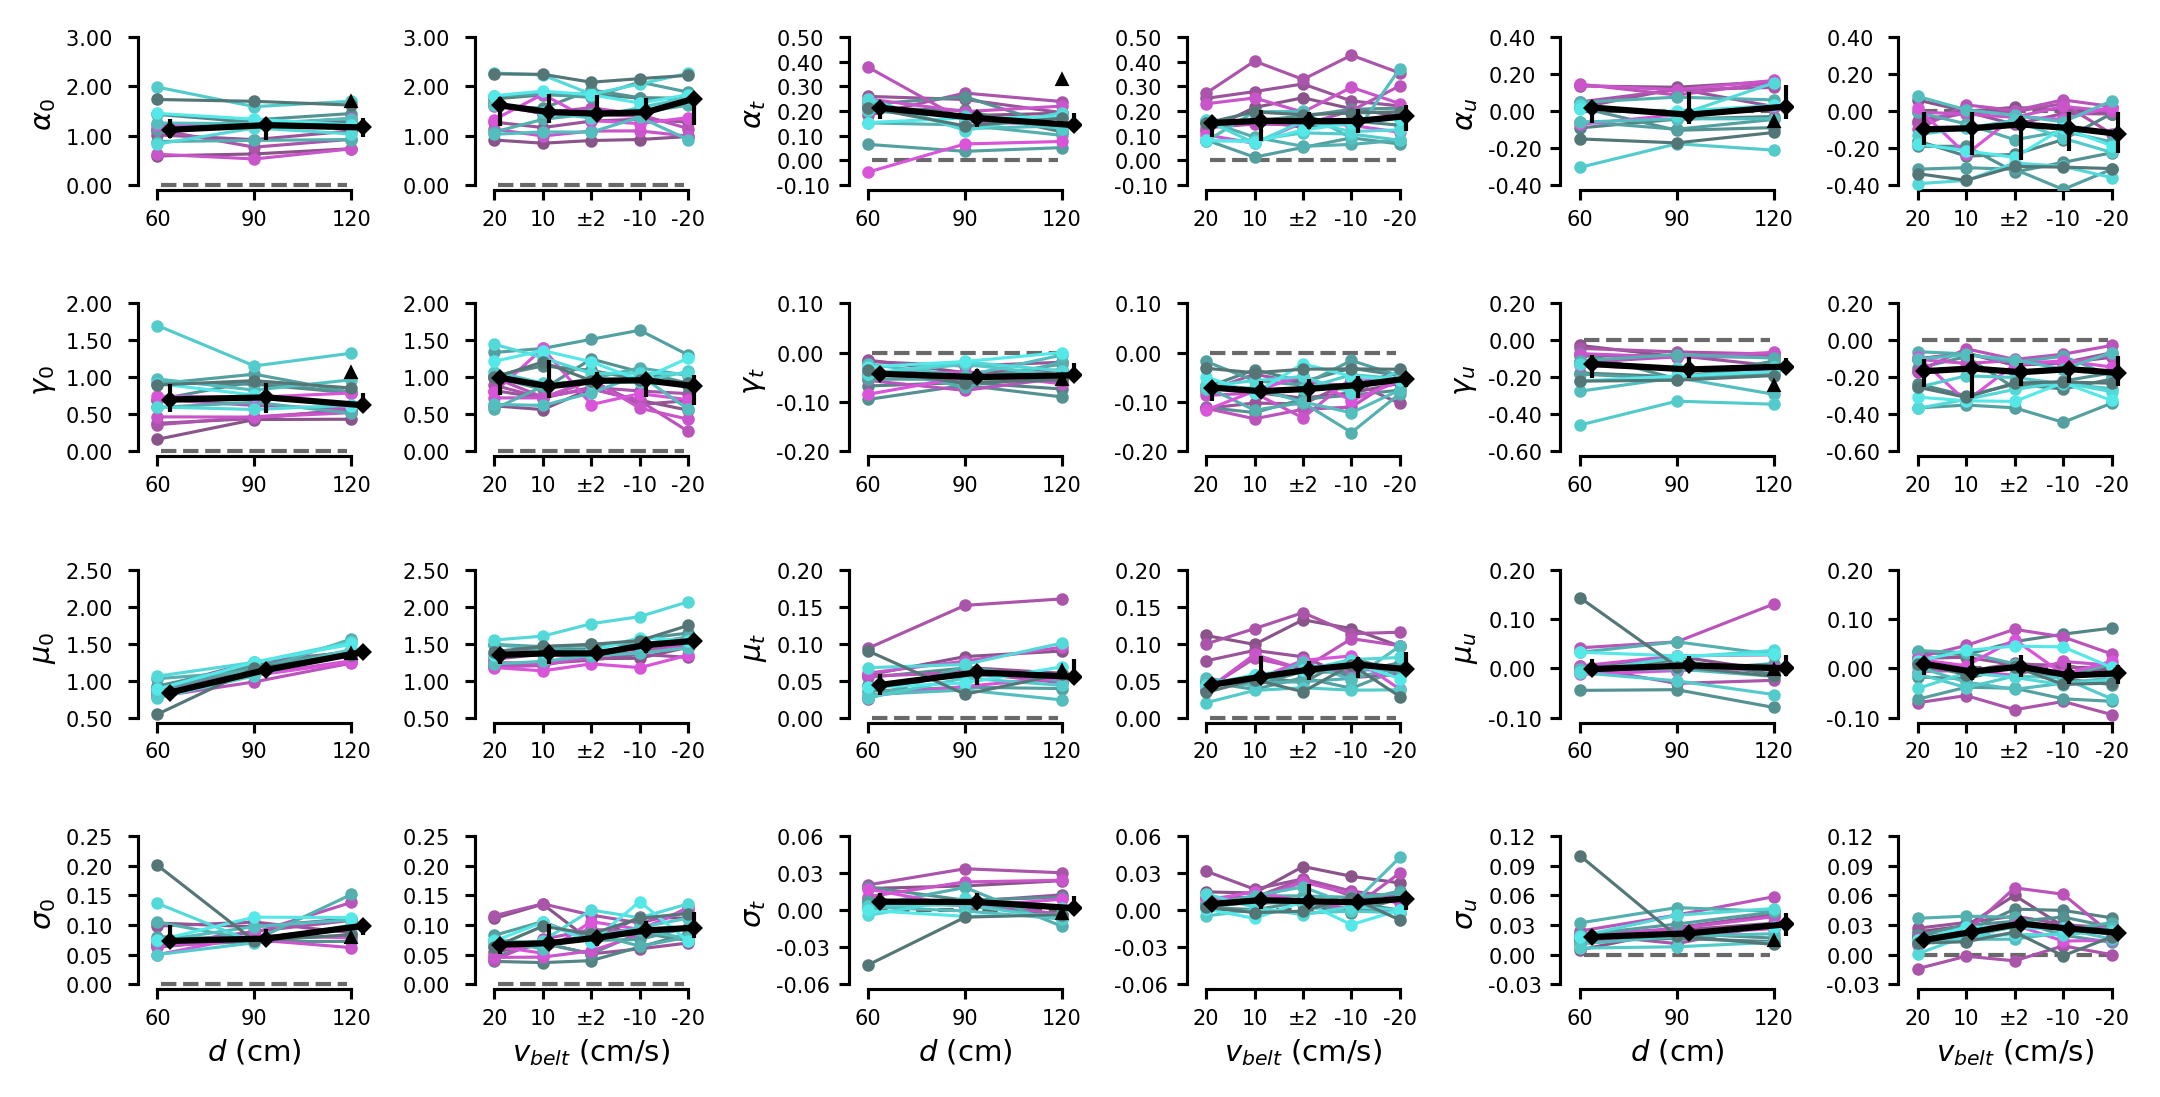

In [ ]:

def plot_model_parameter(param_name, dist_or_tm='dist', show_ex=False, ax=None, show_xlabel=False, show_ylabel=False, hide_y=False,
                         lesioned_animals=False):

    if not lesioned_animals:
        animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']
    else:
        animalList = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]
    if dist_or_tm == 'dist':
        x = [0, 1, 2]
        conds = ["60", "90", "120"]
        xticklabels = ["60", "90", "120"]
        _ = r'$d$'
        xlabel = f'{_} (cm)'
    elif dist_or_tm == 'tm':
        x = [0, 1, 2, 3, 4]
        conds = ["20", "10", "2", "rev10", "rev20"]
        xticklabels = ["20", "10", "±2", "-10", "-20"]
        _ = r'$v_{belt}$'
        xlabel = f'{_} (cm/s)'

    for animal in animalList:
        ax.plot(x, [params['fit'][animal][cond] for cond in conds], 
                    color=rat_markers[animal][0], marker=rat_markers[animal][1], lw=.75,
                    markersize=2, zorder=8 if animal=='RatM00' else 5)
        
    if show_ex:
        ax.plot(2, params['ex_fit'], color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')


    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)

    ax.set_xlim(x[0], x[-1])
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)
    if show_xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel(" ")

    ax.set_ylim(params['yticks'][0], params['yticks'][-1])
    ax.set_yticks(params['yticks'])
    if param_name not in ['run_speed', 'run_speed_lesion']:
        ax.yaxis.set_major_formatter('{x:<5.2f}')
    if show_ylabel:
        ax.set_ylabel(params['ylabel'])
    if hide_y:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False, labelleft=False)

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(params['fit'], ax=ax, dist_or_tm=dist_or_tm, animalList=animalList, err='percentile')


fig, axs = plt.subplots(4, 6, figsize=(cm2inch(18), cm2inch(9)))
param_names = [name for name in list(PLOT_PARAMS.keys()) for _ in (0, 1)]

for i, ax in enumerate(axs.ravel()):
    if i % 2 == 0:
        dist_or_tm = 'dist'
    else:
        dist_or_tm = 'tm'

    show_xlabel = True if i >= 18 else False
    show_ylabel = True if i % 2 == 0 else False
    show_ex = True if i % 2 == 0 else False
    plot_model_parameter(param_names[i], dist_or_tm=dist_or_tm, show_ex=show_ex, ax=ax, 
                         show_xlabel=show_xlabel, show_ylabel=show_ylabel)


# 3E Effect of treadmill on α0, αt and αu
# 3F Effect of treadmill on γ0, γt and γu

# Figure 3: Dynamics of decision parameters across action costs.

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied.  At least one axes collapsed to zero width or height.
  fig.canvas.print_figure(bytes_io, **kw)


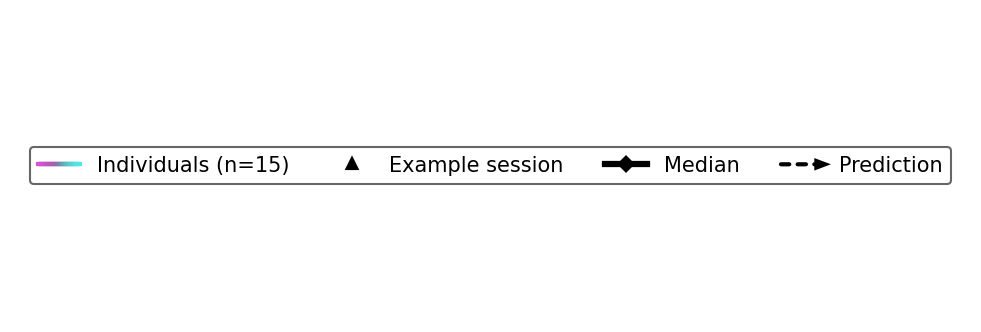

In [7]:

def dummy_legend(ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ex_session = ax.plot(2, 0, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    median = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median', zorder=5)

    class DashedArrowHandler(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent,
                        width, height, fontsize, trans):
            scale = 1.4
            extra = (scale - 1) * width / 2
            start_x = -extra
            end_x = width + extra

            y = 0.5 * height

            # Dashed shaft
            shaft = mpatches.FancyArrowPatch((start_x, y), (end_x, y),
                                            arrowstyle='-',
                                            linestyle=(0, (2, 2)),
                                            lw=1,
                                            color='k',
                                            mutation_scale=fontsize)
            # Solid head
            head = mpatches.FancyArrowPatch((start_x + 0.8*(end_x-start_x), y), (end_x, y),
                                            arrowstyle='-|>,head_width=.3,head_length=.8',
                                            lw=0,
                                            facecolor='k',
                                            edgecolor='k',
                                            mutation_scale=fontsize)

            shaft.set_transform(trans)
            head.set_transform(trans)
            return [shaft, head]


    arrow = mpatches.FancyArrowPatch((0, 0), (1, 0),
                                     arrowstyle='-|>', 
                                     lw=1, 
                                     color='k',
                                     linestyle='--')
    

    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

    add_colored_intact(ax, handles=[ex_session, median, arrow], ncol=4,
                    labels=['Example session', 'Median', 'Prediction'], text=f'Individuals (n={len(animalList)})', 
                    loc='center', bbox=(.5, .5), handler_map={mpatches.FancyArrowPatch: DashedArrowHandler()})


fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

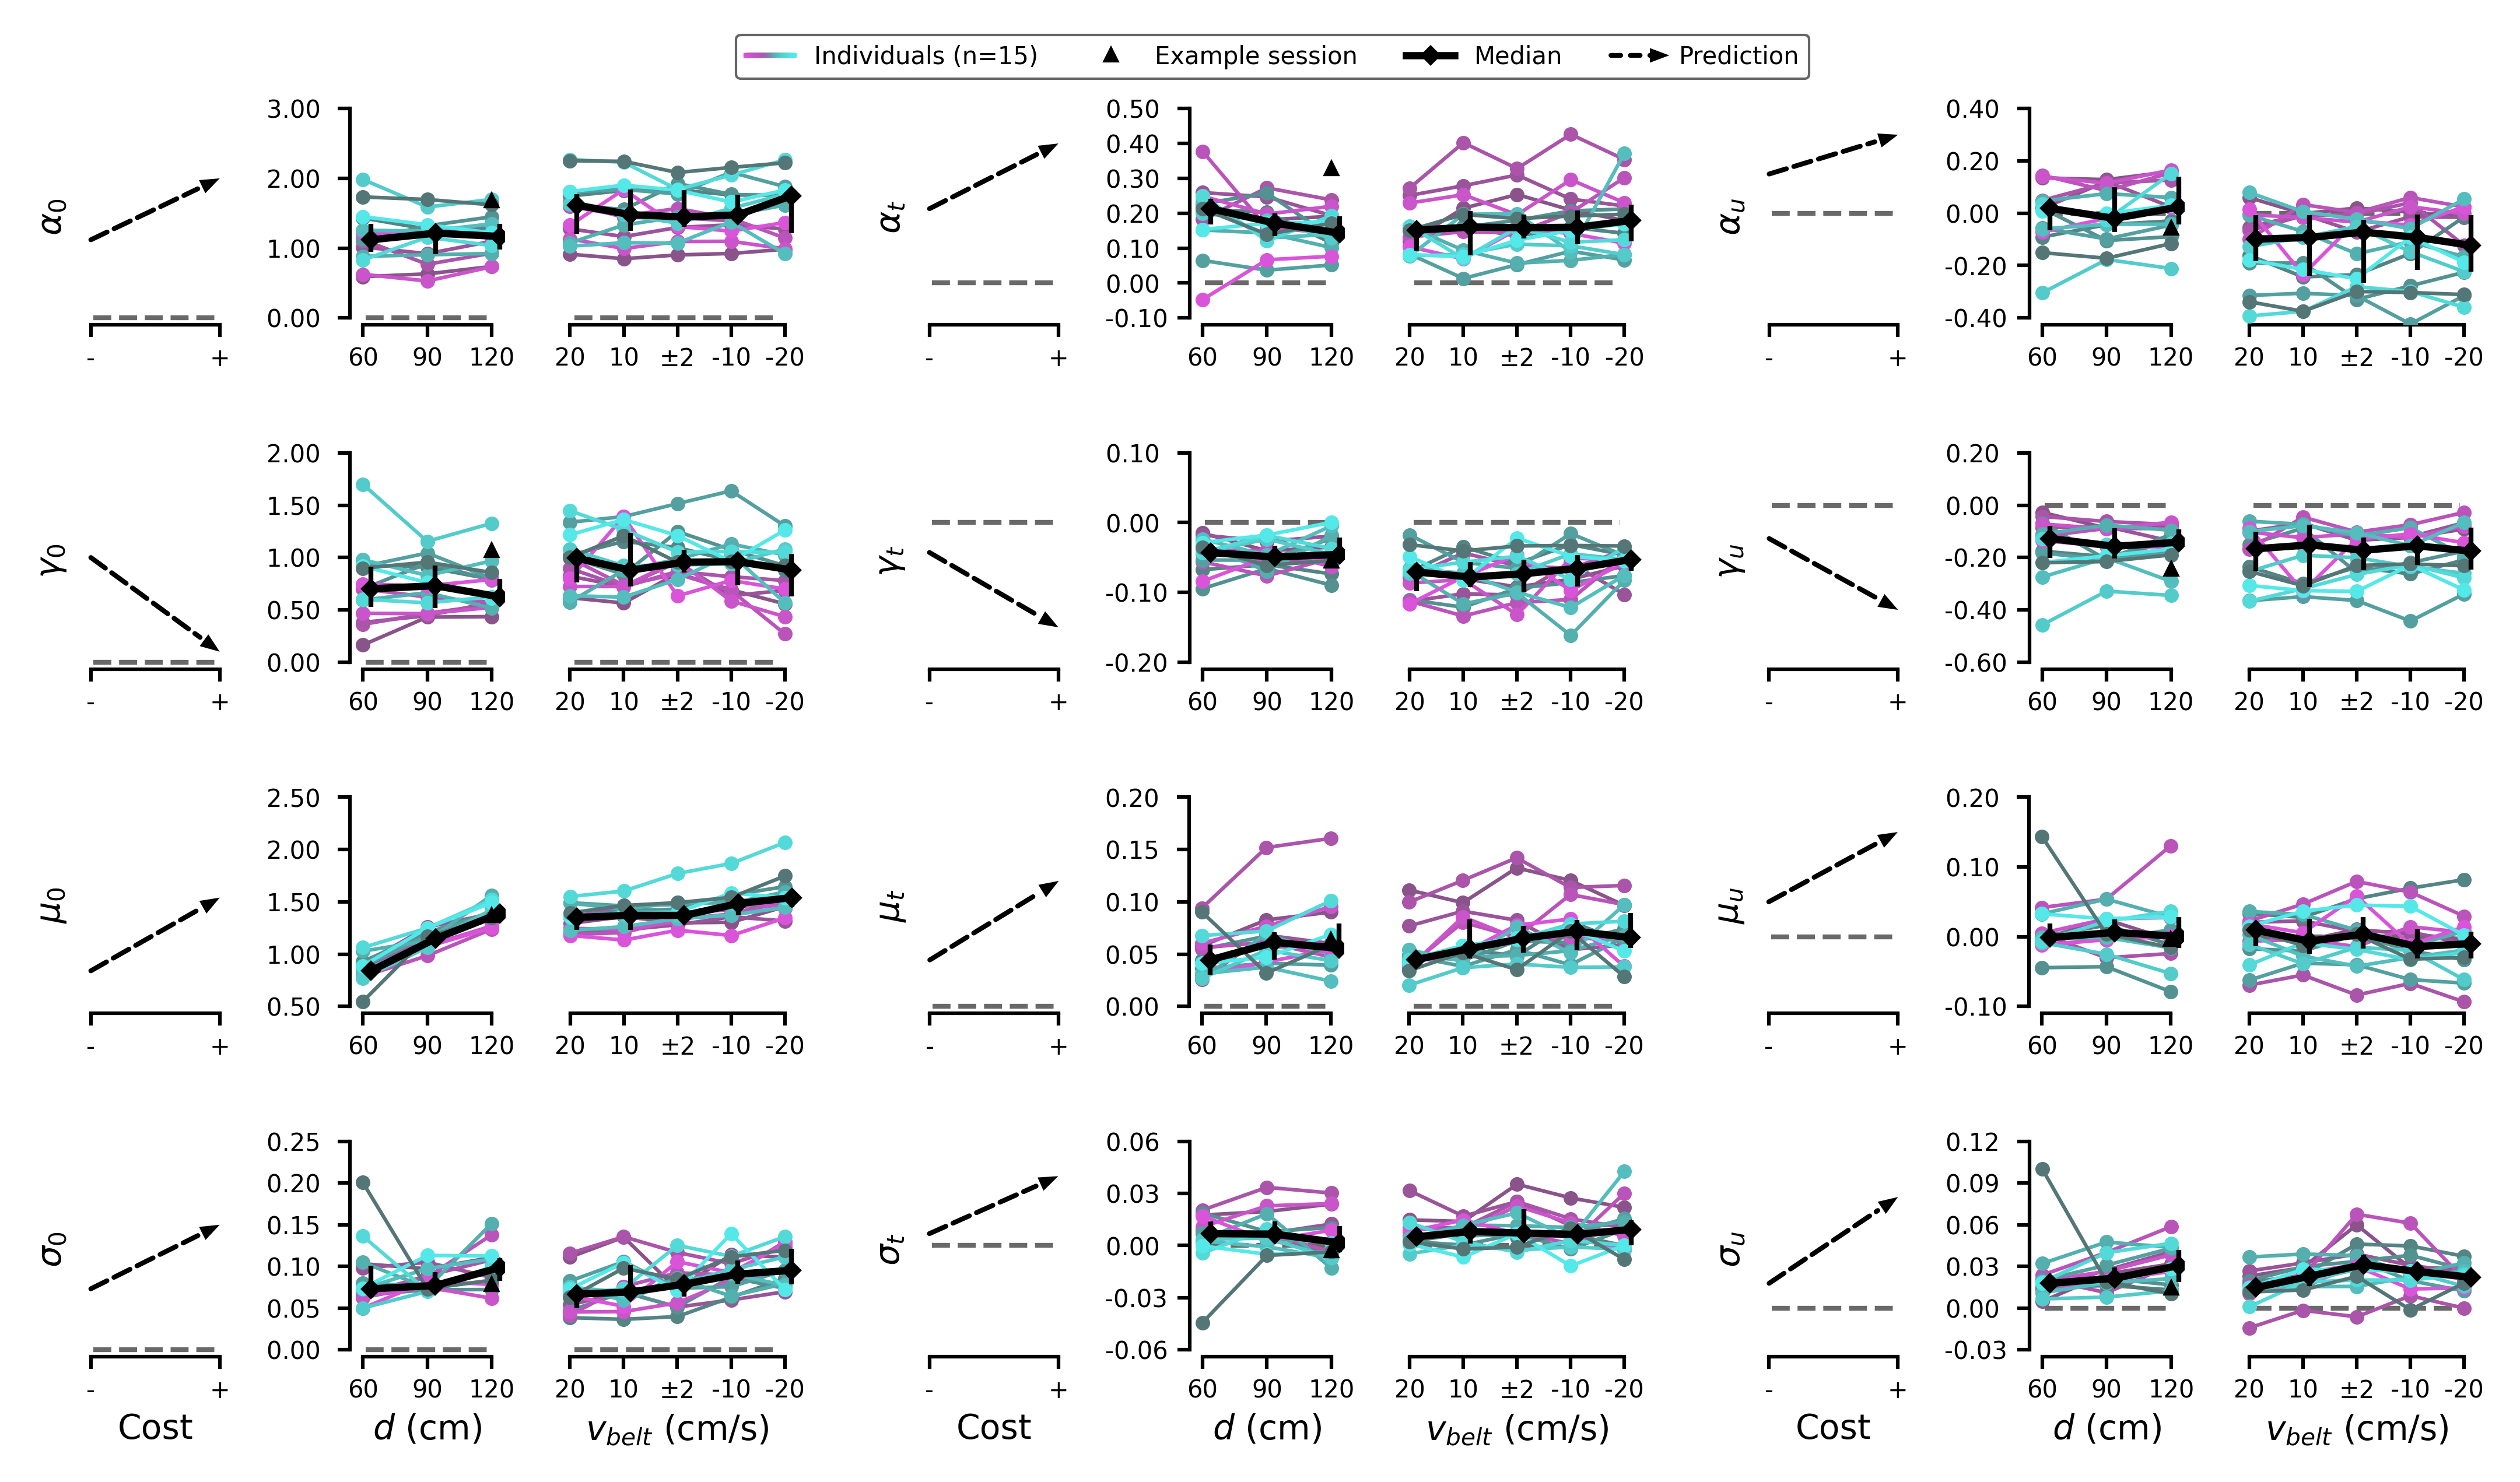

In [8]:

fig = plt.figure(figsize=(cm2inch(18), cm2inch(10)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.0001
width_ratios = [1, 1, 1, pad, 1, 1, 1, pad, 1, 1, 1]
width_ratios = [3, 3, 5, pad, 3, 3, 5, pad, 3, 3, 5]
gs0 = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1])

row1 = gs0[0].subgridspec(1, 11, width_ratios=width_ratios)
ax_prediction_alpha_0 = plt.subplot(row1[0])
fit_alpha_0_distance = plt.subplot(row1[1])
fit_alpha_0_vbelt = plt.subplot(row1[2])

ax_prediction_alpha_t = plt.subplot(row1[4])
fit_alpha_t_distance = plt.subplot(row1[5])
fit_alpha_t_vbelt = plt.subplot(row1[6])

ax_prediction_alpha_u = plt.subplot(row1[8])
fit_alpha_u_distance = plt.subplot(row1[9])
fit_alpha_u_vbelt = plt.subplot(row1[10])

row2 = gs0[1].subgridspec(1, 11, width_ratios=width_ratios)
ax_prediction_gamma_0 = plt.subplot(row2[0])
fit_gamma_0_distance = plt.subplot(row2[1])
fit_gamma_0_vbelt = plt.subplot(row2[2])

ax_prediction_gamma_t = plt.subplot(row2[4])
fit_gamma_t_distance = plt.subplot(row2[5])
fit_gamma_t_vbelt = plt.subplot(row2[6])

ax_prediction_gamma_u = plt.subplot(row2[8])
fit_gamma_u_distance = plt.subplot(row2[9])
fit_gamma_u_vbelt = plt.subplot(row2[10])


row3 = gs0[2].subgridspec(1, 11, width_ratios=width_ratios)
ax_prediction_mu_0 = plt.subplot(row3[0])
fit_mu_0_distance = plt.subplot(row3[1])
fit_mu_0_vbelt = plt.subplot(row3[2])

ax_prediction_mu_t = plt.subplot(row3[4])
fit_mu_t_distance = plt.subplot(row3[5])
fit_mu_t_vbelt = plt.subplot(row3[6])

ax_prediction_mu_u = plt.subplot(row3[8])
fit_mu_u_distance = plt.subplot(row3[9])
fit_mu_u_vbelt = plt.subplot(row3[10])

row4 = gs0[3].subgridspec(1, 11, width_ratios=width_ratios)
ax_prediction_sigma_0 = plt.subplot(row4[0])
fit_sigma_0_distance = plt.subplot(row4[1])
fit_sigma_0_vbelt = plt.subplot(row4[2])

ax_prediction_sigma_t = plt.subplot(row4[4])
fit_sigma_t_distance = plt.subplot(row4[5])
fit_sigma_t_vbelt = plt.subplot(row4[6])

ax_prediction_sigma_u = plt.subplot(row4[8])
fit_sigma_u_distance = plt.subplot(row4[9])
fit_sigma_u_vbelt = plt.subplot(row4[10])


plot_prediction('alpha_0', ax=ax_prediction_alpha_0, show_ylabel=True)
plot_prediction('alpha_t', ax=ax_prediction_alpha_t)
plot_prediction('alpha_u', ax=ax_prediction_alpha_u)
plot_prediction('gamma_0', ax=ax_prediction_gamma_0)
plot_prediction('gamma_t', ax=ax_prediction_gamma_t)
plot_prediction('gamma_u', ax=ax_prediction_gamma_u)
plot_prediction('mu_0', ax=ax_prediction_mu_0)
plot_prediction('mu_t', ax=ax_prediction_mu_t)
plot_prediction('mu_u', ax=ax_prediction_mu_u)
plot_prediction('sigma_0', ax=ax_prediction_sigma_0, show_xlabel=True)
plot_prediction('sigma_t', ax=ax_prediction_sigma_t, show_xlabel=True)
plot_prediction('sigma_u', ax=ax_prediction_sigma_u, show_xlabel=True)


plot_model_parameter('alpha_0', dist_or_tm='dist', show_ex=True, ax=fit_alpha_0_distance, show_ylabel=False)
plot_model_parameter('alpha_t', dist_or_tm='dist', show_ex=True, ax=fit_alpha_t_distance)
plot_model_parameter('alpha_u', dist_or_tm='dist', show_ex=True, ax=fit_alpha_u_distance)
plot_model_parameter('gamma_0', dist_or_tm='dist', show_ex=True, ax=fit_gamma_0_distance)
plot_model_parameter('gamma_t', dist_or_tm='dist', show_ex=True, ax=fit_gamma_t_distance)
plot_model_parameter('gamma_u', dist_or_tm='dist', show_ex=True, ax=fit_gamma_u_distance)
plot_model_parameter('mu_0', dist_or_tm='dist', show_ex=True, ax=fit_mu_0_distance)
plot_model_parameter('mu_t', dist_or_tm='dist', show_ex=True, ax=fit_mu_t_distance)
plot_model_parameter('mu_u', dist_or_tm='dist', show_ex=True, ax=fit_mu_u_distance)
plot_model_parameter('sigma_0', dist_or_tm='dist', show_ex=True, ax=fit_sigma_0_distance, show_xlabel=True)
plot_model_parameter('sigma_t', dist_or_tm='dist', show_ex=True, ax=fit_sigma_t_distance, show_xlabel=True)
plot_model_parameter('sigma_u', dist_or_tm='dist', show_ex=True, ax=fit_sigma_u_distance, show_xlabel=True)


plot_model_parameter('alpha_0', dist_or_tm='tm', show_ex=False, ax=fit_alpha_0_vbelt, hide_y=True)
plot_model_parameter('alpha_t', dist_or_tm='tm', show_ex=False, ax=fit_alpha_t_vbelt, hide_y=True)
plot_model_parameter('alpha_u', dist_or_tm='tm', show_ex=False, ax=fit_alpha_u_vbelt, hide_y=True)
plot_model_parameter('gamma_0', dist_or_tm='tm', show_ex=False, ax=fit_gamma_0_vbelt, hide_y=True)
plot_model_parameter('gamma_t', dist_or_tm='tm', show_ex=False, ax=fit_gamma_t_vbelt, hide_y=True)
plot_model_parameter('gamma_u', dist_or_tm='tm', show_ex=False, ax=fit_gamma_u_vbelt, hide_y=True)
plot_model_parameter('mu_0', dist_or_tm='tm', show_ex=False, ax=fit_mu_0_vbelt, hide_y=True)
plot_model_parameter('mu_t', dist_or_tm='tm', show_ex=False, ax=fit_mu_t_vbelt, hide_y=True)
plot_model_parameter('mu_u', dist_or_tm='tm', show_ex=False, ax=fit_mu_u_vbelt, hide_y=True)
plot_model_parameter('sigma_0', dist_or_tm='tm', show_ex=False, ax=fit_sigma_0_vbelt, show_xlabel=True, hide_y=True)
plot_model_parameter('sigma_t', dist_or_tm='tm', show_ex=False, ax=fit_sigma_t_vbelt, show_xlabel=True, hide_y=True)
plot_model_parameter('sigma_u', dist_or_tm='tm', show_ex=False, ax=fit_sigma_u_vbelt, show_xlabel=True, hide_y=True)


legend = fig.add_axes([.5, 1.015, .01, .01])
dummy_legend(ax=legend)

plt.savefig("./Figures_paper/Figure_3.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_3.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)